In [1]:
!pip -q install open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00


In [2]:

import json
import random
from pathlib import Path

import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from torchvision.datasets import STL10
from torchvision import transforms
from torchvision.transforms import InterpolationMode

SEED = 6304

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device( "cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)

Device: cpu
PyTorch: 2.11.0+cpu
TorchVision: 0.26.0+cpu


In [3]:

from google.colab import drive

drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/drive/MyDrive/pa1-beyond-iid")

DATA_ROOT = Path("/content/stl10-data")

folders = [
            "task1/configs",
            "task1/data",
            "task1/models",
            "task1/analysis",
            "task1/scripts",
            "task1/results",
            "task1/figures",
            "task1/notebooks",
            "task2",
            "task3",
            "task4",
            "report",
          ]

PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
DATA_ROOT.mkdir(parents=True, exist_ok=True)

for folder in folders:
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)

print("Project:", PROJECT_ROOT)
print("Dataset:", DATA_ROOT)
print("Directories created successfully.")

Mounted at /content/drive
Project: /content/drive/MyDrive/pa1-beyond-iid
Dataset: /content/stl10-data
Directories created successfully.


In [4]:

train_dataset = STL10(root=str(DATA_ROOT), split="train", download=True)

test_dataset = STL10(root=str(DATA_ROOT), split="test", download=False)

CLASS_NAMES = list(train_dataset.classes)

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))
print("Classes:", CLASS_NAMES)

image, label = train_dataset[0]

print("Image size:", image.size)
print("Image mode:", image.mode)
print("First label:", CLASS_NAMES[label])

100%|██████████| 2.64G/2.64G [13:19<00:00, 3.30MB/s]


Training images: 5000
Testing images: 8000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
Image size: (96, 96)
Image mode: RGB
First label: bird


In [5]:

all_indices = np.arange(len(train_dataset))

train_indices, val_indices = train_test_split(all_indices, test_size=0.20, random_state=SEED, stratify=train_dataset.labels)
train_indices = np.sort(train_indices)
val_indices = np.sort(val_indices)

print("Training:", len(train_indices))
print("Validation:", len(val_indices))

assert len(train_indices) == 4000
assert len(val_indices) == 1000

assert len(set(train_indices) & set(val_indices)) == 0

for class_id, class_name in enumerate(CLASS_NAMES):
    train_count = np.sum(train_dataset.labels[train_indices] == class_id)

    val_count = np.sum(train_dataset.labels[val_indices] == class_id)

    print(class_name, "Train:", train_count, "Val:", val_count)

Training: 4000
Validation: 1000
airplane Train: 400 Val: 100
bird Train: 400 Val: 100
car Train: 400 Val: 100
cat Train: 400 Val: 100
deer Train: 400 Val: 100
dog Train: 400 Val: 100
horse Train: 400 Val: 100
monkey Train: 400 Val: 100
ship Train: 400 Val: 100
truck Train: 400 Val: 100


In [6]:

rng = np.random.default_rng(SEED)

test_indices = []

for class_id in range(len(CLASS_NAMES)):
    candidates = np.where(test_dataset.labels == class_id)[0]
    count = min(50, len(candidates))
    chosen = rng.choice(candidates, size=count, replace=False)
    test_indices.extend(chosen.tolist())

test_indices = np.array(sorted(test_indices), dtype=int)

assert len(test_indices) == 500
assert len(np.unique(test_indices)) == 500

print("Selected evaluation images:", len(test_indices))

Selected evaluation images: 500


In [7]:

split_data = {
                "dataset": "STL10",
                "seed": SEED,
                "classes": CLASS_NAMES,
                "train_indices": train_indices.tolist(),
                "validation_indices": val_indices.tolist(),
                "test_indices": test_indices.tolist()
             }

split_path = (PROJECT_ROOT / "task1/data/split_indices.json")

with open(split_path, "w") as f:
    json.dump(split_data, f, indent=2)

print("Saved:", split_path)

Saved: /content/drive/MyDrive/pa1-beyond-iid/task1/data/split_indices.json


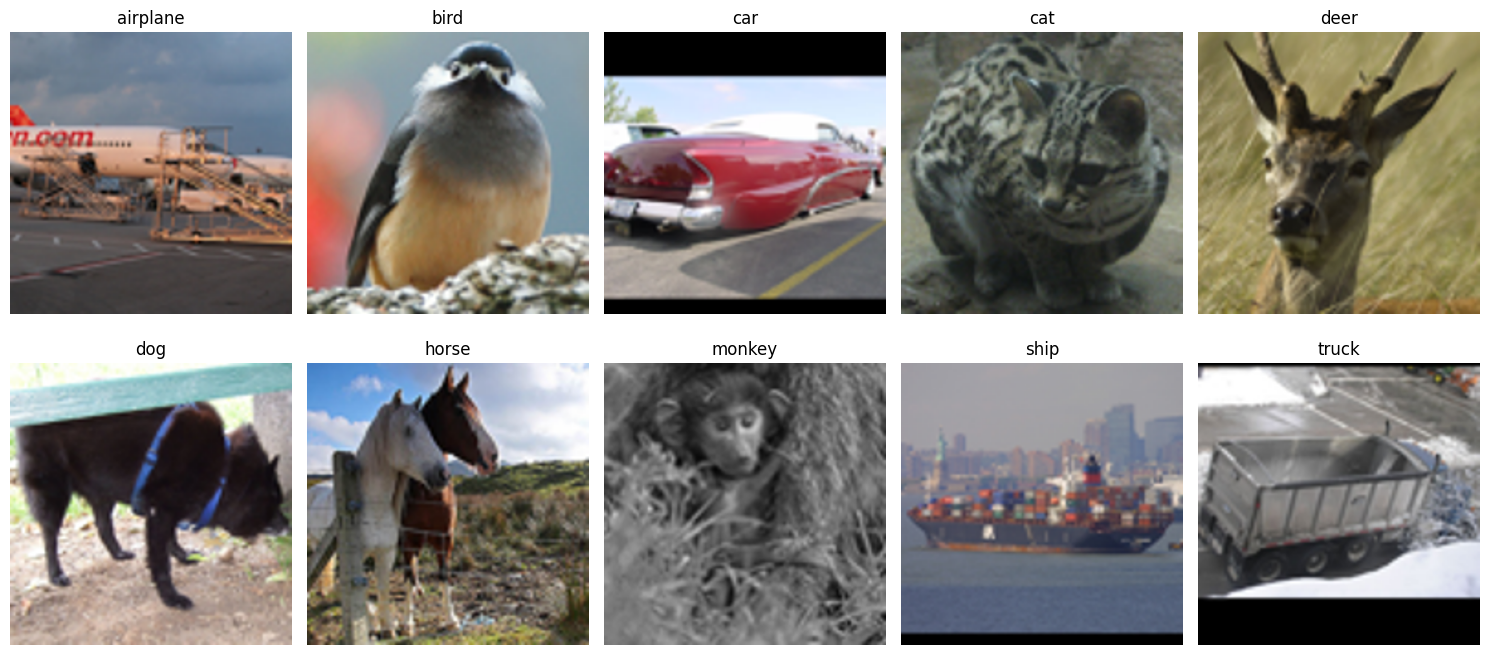

In [8]:

resize = transforms.Resize((224, 224), interpolation=InterpolationMode.BICUBIC)

def canonical_image(image):
    image = image.convert("RGB")
    image = resize(image)
    return image

example_indices = []

for class_id in range(len(CLASS_NAMES)):
    matching = [int(idx) for idx in test_indices if test_dataset.labels[idx] == class_id]
    example_indices.append(matching[0])

fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for ax, idx in zip(axes.flat, example_indices):

    image, label = test_dataset[idx]
    image = canonical_image(image)

    ax.imshow(image)
    ax.set_title(CLASS_NAMES[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
import numpy as np

export_path = (PROJECT_ROOT / "task1/data/stl10_labeled.npz")

np.savez_compressed(
                    export_path,
                    train_images=train_dataset.data,
                    train_labels=np.asarray(train_dataset.labels),
                    test_images=test_dataset.data[test_indices],
                    test_labels=np.asarray(test_dataset.labels)[test_indices],
                    test_indices=test_indices,
                    class_names=np.asarray(CLASS_NAMES)
                   )

print("Dataset exported to:", export_path)

Dataset exported to: /content/drive/MyDrive/pa1-beyond-iid/task1/data/stl10_labeled.npz
